<a href="https://colab.research.google.com/github/AkkiNikumbh/DL-EXPERIMENTS/blob/main/AkashSingh_23CS036_Exp7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
# Install yfinance for data fetching
!pip install yfinance -q

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

print("Setup Complete")

Setup Complete


In [4]:
# 1. Download Historical Data
ticker = 'AAPL'
data = yf.download(ticker, start='2015-01-01', end='2023-12-31')

# 2. Scale the data (LSTMs are sensitive to scale)
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[['Close']].values)

# 3. Create training sequences (60 days of history to predict the next day)
prediction_days = 60
x_train, y_train = [], []

for i in range(prediction_days, len(scaled_data)):
    x_train.append(scaled_data[i-prediction_days:i, 0])
    y_train.append(scaled_data[i, 0])

x_train, y_train = np.array(x_train), np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

print(f"Training data shape: {x_train.shape}")

/tmp/ipykernel_31589/2707077174.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, start='2015-01-01', end='2023-12-31')
[*********************100%***********************]  1 of 1 completed

Training data shape: (2204, 60, 1)


In [5]:
# Initialize the RNN
model = Sequential([
    # First LSTM layer
    LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    Dropout(0.2),
    # Second LSTM layer
    LSTM(units=50, return_sequences=False),
    Dropout(0.2),
    # Output layers
    Dense(units=25),
    Dense(units=1)
])

# Compile and Train
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, batch_size=32, epochs=10)

Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


69/69 ━━━━━━━━━━━━━━━━━━━━ 8s 61ms/step - loss: 0.0152
Epoch 2/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 74ms/step - loss: 0.0027
Epoch 3/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 57ms/step - loss: 0.0022
Epoch 4/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 55ms/step - loss: 0.0023
Epoch 5/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 6s 69ms/step - loss: 0.0018
Epoch 6/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0015
Epoch 7/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 53ms/step - loss: 0.0015
Epoch 8/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 5s 73ms/step - loss: 0.0015
Epoch 9/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0014
Epoch 10/10
69/69 ━━━━━━━━━━━━━━━━━━━━ 4s 54ms/step - loss: 0.0016


/tmp/ipykernel_31589/2019735378.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  test_data = yf.download(ticker, start='2024-01-01', end='2024-06-01')
[*********************100%***********************]  1 of 1 completed


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 113ms/step


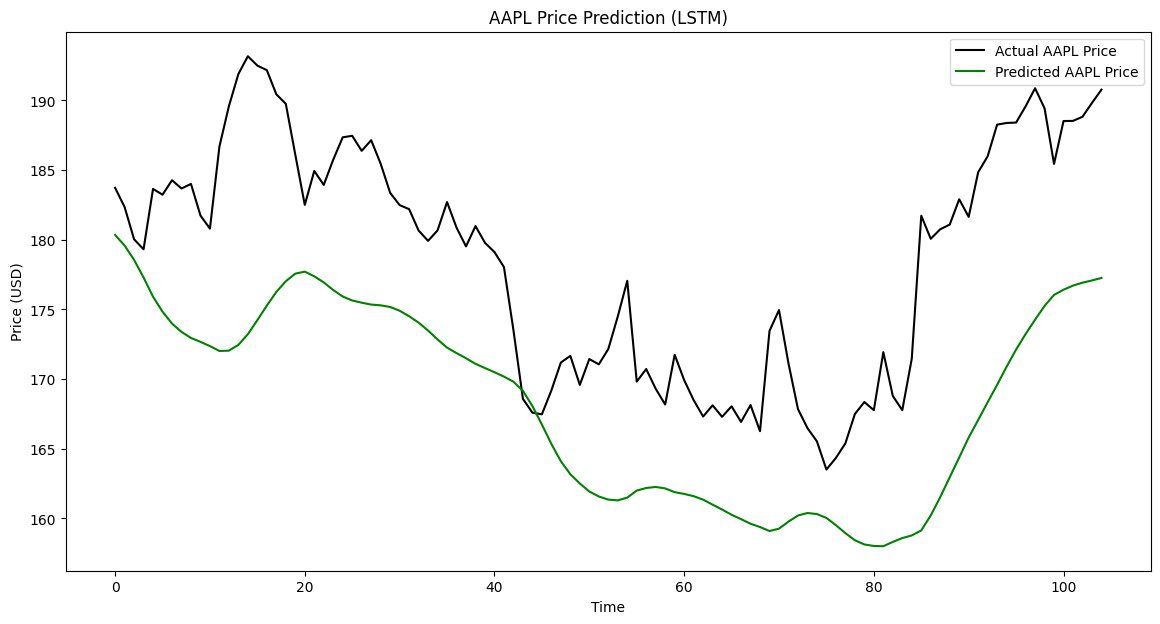

In [6]:
# 1. Get Test Data (2024 onwards)
test_data = yf.download(ticker, start='2024-01-01', end='2024-06-01')
actual_prices = test_data['Close'].values

# 2. Prepare inputs for prediction
total_dataset = pd.concat((data['Close'], test_data['Close']), axis=0)
model_inputs = total_dataset[len(total_dataset) - len(test_data) - prediction_days:].values
model_inputs = model_inputs.reshape(-1, 1)
model_inputs = scaler.transform(model_inputs)

x_test = []
for i in range(prediction_days, len(model_inputs)):
    x_test.append(model_inputs[i-prediction_days:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# 3. Predict and Inverse Scale
predicted_prices = model.predict(x_test)
predicted_prices = scaler.inverse_transform(predicted_prices)

# 4. Plot Results
plt.figure(figsize=(14,7))
plt.plot(actual_prices, color='black', label=f'Actual {ticker} Price')
plt.plot(predicted_prices, color='green', label=f'Predicted {ticker} Price')
plt.title(f'{ticker} Price Prediction (LSTM)')
plt.xlabel('Time')
plt.ylabel('Price (USD)')
plt.legend()
plt.show()